# Synthesizing Data for Healthcare Records

Highly sensitive data, such as patient health records, is challenging to analyze and share. Using SDV, you can train generative AI models on your sensitive datasets and then use them to generate synthetic data. The synthetic data mirrors the statistical patterns in your real data and even adheres to the same business logic, but synthetic data will not expose explicit information on specific individuals.

In this tutorial, we will generate synthetic data for healthcare records. We will focus on inspecting the data properties and making sure we configure the synthesizer properly to model the data.

In [1]:
import warnings

warnings.filterwarnings("ignore")

## Understanding the Data

We'll be using a dataset called [SyntheaMass](https://synthea.mitre.org/downloads), which is a multi-table, healthcare dataset containing tables on patients, payers, and more. We'll treat this dataset as our real, sensitive data, use it to train a model in SDV, and finally use that model to generate synthetic data.

Here's a description of the tables in this dataset:

| Table               | Description                                                                                                               |
|---------------------|---------------------------------------------------------------------------------------------------------------------------|
| patients            | Patient info, including key dates, identifiers, address, and race information                                             |
| encounters          | Patients' encounters with the healthcare system (outpatient care, ambulance care, etc), including dates, payer, and cost. |
| medications         | Patients' medication history, including dates, payer, and cost.                                                           |
| careplans           | Patients' treatment plans, including dates, and type.                                                                     |
| immunizations       | Patients' immunization records, including cost and type.                                                                  |
| observations        | Patients' recorded health metrics, including type and units.                                                              |
| imaging_studies     | Imaging procedure records for patients, including procedure and modality codes.                                           |
| devices             | Issued medical devices to patients, including dates and types.                                                            |
| supplies            | Information on health supplies patients receive or use, including dates and types.                                        |
| allergies           | Patients' allergy records, including dates, severity, and type.                                                           |
| procedures          | Patients' medical procedures, including dates, codes, and reasons.                                                        |
| conditions          | Patients' medical conditions, including dates and description.                                                            |
| payers              | Payer info, including location, revenue, and amount covered.                                                              |
| payer_transitions   | Info on patients and their insurance payer over time, including dates and ownership.                                      |
| organizations       | Info on healthcare organizations, like clinics and hospitals, including location, utilization, and revenue.               |
| providers           | Info on specific clinicians, including location and utilization.                                                          |
| claims              | Info on all insurance claims on behalf of patients, including diagnoses, appointments, statuses, and billing dates.       |
| claims_transactions | Info on all payments made to settle claims, including diagnoses, appointments, and payment details.                       |

This dataset is available as a demo dataset in SDV. To load the datasets we can use the `download_demo` functionality and pass in `synthea` as the name of the dataset. The function will retrieve the dataset and its associated metadata.

Let's start by downloading the data then check that it contains 18 tables.

In [2]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(modality="multi_table", dataset_name="synthea")
real_data.keys()

dict_keys(['allergies', 'careplans', 'claims', 'claims_transactions', 'conditions', 'devices', 'encounters', 'imaging_studies', 'immunizations', 'medications', 'observations', 'organizations', 'patients', 'payer_transitions', 'payers', 'procedures', 'providers', 'supplies'])

## Updating the Data

First, we will preprocess a few columns in the data.

The `payer_transitions` table has `START_YEAR` and `END_YEAR` columns that store full timestamps, but only the year is meaningful. 

Let's convert them to year-only strings:

In [3]:
import pandas as pd

for column_name in ["START_YEAR", "END_YEAR"]:
    real_data["payer_transitions"][column_name] = pd.to_datetime(
        real_data["payer_transitions"][column_name]
    ).dt.strftime("%Y")

Some columns in the data are entirely null and aren't useful for SDV, so let's drop them.

In [4]:
null_columns_dict = {}

for table_name, df in real_data.items():
    null_columns = df.columns[df.isnull().all()]
    null_columns_dict[table_name] = null_columns.tolist()
    real_data[table_name].drop(columns=null_columns, inplace=True)

We have completed preprocessing the data. 

## Updating the Metadata
The metadata is already provided to us, but in cases where we do not have it, we can use SDV's detection functionality to create an initial version of the metadata:

```python
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(real_data)
```


If we visualize the metadata in a diagram, the complexity of the data stands out to us immediately.

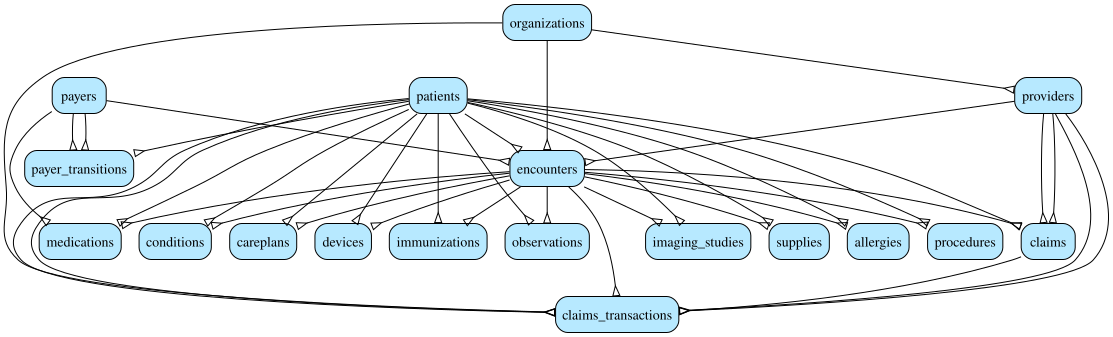

In [5]:
metadata.visualize(show_table_details=None, show_relationship_labels=False)

SDV automatically identified all of the key relationships between the tables in the data, so no updates are needed here. Identifying the right sdtype automatically is much more challenging and an imperfect process, so we'll need to inspect the metadata and manually update the sdtypes if needed.

First, let's update the metadata for the `organizations` table. The majority of the fields in this table were assigned the `unknown` sdtype, which means that SDV will have a hard time generating high-quality synthetic values for these columns.

Some columns in the `organizations` table with their correct sdtype:

| Column            | Correct SDType | Reason                                                                                   |
|-------------------|----------------|------------------------------------------------------------------------------------------|
| NAME              | categorical    | This will ensure the same organization names are replicated in the synthetic data.       |
| ADDRESS           | address        | SDV will know to generate realistic addresses                                            |
| ZIP               | postcode       | SDV will know to generate realistic postal codes                                         |
| LAT               | latitude       | SDV will know to generate realistic latitude values                                      |
| LON               | longitude      | SDV will know to generate realistic longitude values                                     |
| PHONE             | phone_number   | SDV will know to generate realistic phone numbers                                        |
| REVENUE           | numerical      | SDV will estimate the distribution in the real data and mirror it in the synthetic data. |

We can run the following code snippet to update our metadata to reflect these changes:

In [6]:
metadata.update_columns_metadata(
    table_name="organizations",
    column_metadata={
        "NAME": {"sdtype": "categorical"},
        "ADDRESS": {"sdtype": "address"},
        "ZIP": {"sdtype": "postcode"},
        "LAT": {"sdtype": "latitude"},
        "LON": {"sdtype": "longitude"},
        "PHONE": {"sdtype": "phone_number"},
        "REVENUE": {"sdtype": "numerical"},
    },
)

Next, let's update the `conditions` table.

| Column            | Correct SDType | Reason                                                                                       |
|-------------------|----------------|----------------------------------------------------------------------------------------------|
| START             | datetime       | Let’s specify the datetime format for SDV to use during synthesis.                           |
| STOP              | datetime       | Let’s specify the datetime format for SDV to use during synthesis.                           |
| CODE              | categorical    | The values in this column are fixed and we want SDV to replicate them in the synthetic data. |


We can run the following code snippet to update our metadata to reflect these changes:

In [7]:
metadata.update_columns_metadata(
    table_name="conditions",
    column_metadata={
        "START": {"sdtype": "datetime", "datetime_format": "%Y-%m-%d"},
        "STOP": {"sdtype": "datetime", "datetime_format": "%Y-%m-%d"},
        "CODE": {"sdtype": "categorical"},
    },
)

Next, let's update the `payer_transitions` table. The `START_YEAR` and `END_YEAR` columns should specify the proper datetime format (`"%Y"`).

We can run the following code snippet to update our metadata:

In [8]:
metadata.update_columns_metadata(
    table_name="payer_transitions",
    column_metadata={
        "START_YEAR": {"sdtype": "datetime", "datetime_format": "%Y"},
        "END_YEAR": {"sdtype": "datetime", "datetime_format": "%Y"},
    },
)

A few other tables (`procedures`, `encounters`, `devices`) have `START` and `STOP` datetime columns that need their datetime format to be defined. 

We will update them all:

In [9]:
for table_name in ["procedures", "encounters", "devices"]:
    metadata.update_columns_metadata(
        table_name=table_name,
        column_metadata={
            "START": {"sdtype": "datetime", "datetime_format": "%Y-%m-%dT%H:%M:%SZ"},
            "STOP": {"sdtype": "datetime", "datetime_format": "%Y-%m-%dT%H:%M:%SZ"},
        },
    )

The `claims` table has a datetime column (`CURRENTILLNESSDATE`) that needs its format specified:

In [10]:
metadata.update_columns_metadata(
    table_name="claims",
    column_metadata={
        "CURRENTILLNESSDATE": {
            "sdtype": "datetime",
            "datetime_format": "%Y-%m-%dT%H:%M:%SZ",
        }
    },
)

Earlier, we dropped columns that were entirely null from the data. We need to remove those same columns from the metadata so it stays in sync with the data.

In [11]:
for table_name, columns in null_columns_dict.items():
    for column_name in columns:
        metadata.remove_column(column_name=column_name, table_name=table_name)

We have now completed updating the metadata.

Now, let's validate the metadata. The following lines of code will validate that our metadata follows the spec that SDV expects and then will validate that the metadata accurately describes the dataset. If both validate successfully, we will see no output.

In [12]:
metadata.validate()
metadata.validate_data(real_data)

## Auto-Detecting Constraints

Constraints are deterministic rules that every row in your data must follow to be considered valid. By default, SDV synthesizers are probabilistic, so they may not learn to match these rules 100% of the time. SDV is able to automatically identify common business rules in your dataset and add them as constraints.

Constraints can be isolated to a [single-table](https://docs.sdv.dev/sdv/concepts/constraint-augmented-generation-cag/predefined-constraints#single-table) or can be applied across [multiple tables](https://docs.sdv.dev/sdv/concepts/constraint-augmented-generation-cag/predefined-constraints#multi-table). 

Let's walk through a few tables and auto-detect constraints in them.

First, we will use constraint auto-detection for the `CarryOverColumns` constraint, a multi-table constraint. This applies when you observe the same column(s) in different tables, and the values of those columns have to match up according to a key (ID) column.

To automatically detect constraints, we first initialize a synthesizer and then call the [detect_constraints](https://docs.sdv.dev/sdv/concepts/constraint-augmented-generation-cag/auto-detect-constraints#less-than-synthesizer-instance-greater-than.detect_constraints) method. We pass `constraint_classes=['CarryOverColumns']` to limit detection to the `CarryOverColumns` constraint, and `table_names=['immunizations', 'claims', 'encounters']` to limit detection to those tables.

In [13]:
from sdv.multi_table import HSASynthesizer

synthesizer = HSASynthesizer(metadata)
detected_constraints = synthesizer.detect_constraints(
    real_data,
    constraint_classes=["CarryOverColumns"],
    table_names=["immunizations", "claims", "encounters"],
)

Detecting constraints: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.36s/it]
3 Constraints Detected

0. CarryOverColumns(common_column_info=[{'table_name': 'claims', 'carryover_column_name': 'PATIENTID', 'key_column_name': 'APPOINTMENTID'}, {'table_name': 'encounters', 'carryover_column_name': 'PATIENT', 'key_column_name': 'Id'}, {'table_name': 'immunizations', 'carryover_column_name': 'PATIENT', 'key_column_name': 'ENCOUNTER'}])
1. CarryOverColumns(common_column_info=[{'table_name': 'claims', 'carryover_column_name': 'SERVICEDATE', 'key_column_name': 'APPOINTMENTID'}, {'table_name': 'encounters', 'carryover_column_name': 'START', 'key_column_name': 'Id'}, {'table_name': 'immunizations', 'carryover_column_name': 'DATE', 'key_column_name': 'ENCOUNTER'}])
2. CarryOverColumns(common_column_info=[{'table_name': 'claims', 'carryover_column_name': 'PROVIDERID', 'key_column_name': 'APPOINTMENTID'

SDV found 3 `CarryOverColumns` constraints. 

The auto-detection will provide you with a list of valid candidate constraints based on your real data. We recommend reviewing all the detected constraints to ensure they are logical before adding them to the synthesizer.

After examining the detected CarryOverColumns constraints, we will only select a single constraint, the one indexed by `1`.
Let's look at the column definitions for the columns in that selected constraint:

| Table | Column | Key Column | Description |
|---|---|---|---|
| `immunizations` | `DATE` | `ENCOUNTER` | The date the immunization was administered. |
| `claims` | `SERVICEDATE` | `APPOINTMENTID` | The date of the services on the claim. |
| `encounters` | `START` | `Id` | The date and time the encounter started. |

It's reasonable to expect this date to carry across tables: a patient receives an immunization, the insurance claim is filed the same day, and the encounter records when it took place.

The other auto-detected `CarryOverColumns` constraints are disregarded because their `carryover_column_name` references a foreign key.

Let's add this constraint to the synthesizer using the [add_constraints](https://docs.sdv.dev/sdv/concepts/constraint-augmented-generation-cag/auto-detect-constraints#less-than-synthesizer_instance-greater-than.add_constraints) method.

In [14]:
synthesizer.add_constraints([detected_constraints[1]])

Next, let's auto-detect `FixedCombinations` constraints in the `immunizations` table. 

The `FixedCombinations` constraint is a single-table constraint that enforces that the combinations between a set of columns are fixed. That is, no other permutations or shuffling is allowed other than what's already observed in the data.

In [15]:
detected_constraints = synthesizer.detect_constraints(
    real_data,
    constraint_classes=["FixedCombinations"],
    table_names=["immunizations"],
)

Detecting constraints: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 90.93it/s]
1 Constraints Detected

0. FixedCombinations(column_names=['CODE', 'DESCRIPTION'], table_name='immunizations')


In this table, SDV detected 1 `FixedCombinations` constraint. The values in these column groups always appear together as fixed sets.
For example, the CODE `140` is always paired with the DESCRIPTION `Influenza  seasonal  injectable  preservative free`.

In [16]:
real_data["immunizations"][["CODE", "DESCRIPTION"]].value_counts().head()

CODE  DESCRIPTION                                                                                  
140   Influenza  seasonal  injectable  preservative free                                               9538
113   Td (adult) preservative free                                                                      815
208   SARS-COV-2 (COVID-19) vaccine  mRNA  spike protein  LNP  preservative free  30 mcg/0.3mL dose     725
20    DTaP                                                                                              604
133   Pneumococcal conjugate PCV 13                                                                     559
Name: count, dtype: int64

`FixedCombinations` constraints can span more than two columns, and a single table can have multiple non-overlapping constraints.

Let's auto-detect `FixedCombinations` constraints for the `imaging_studies` table:

In [17]:
detected_constraints = synthesizer.detect_constraints(
    real_data,
    constraint_classes=["FixedCombinations"],
    table_names=["imaging_studies"],
)

Detecting constraints: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.89it/s]
2 Constraints Detected

0. FixedCombinations(column_names=['SERIES_UID', 'BODYSITE_CODE', 'BODYSITE_DESCRIPTION', 'MODALITY_CODE', 'MODALITY_DESCRIPTION'], table_name='imaging_studies')
1. FixedCombinations(column_names=['SOP_CODE', 'SOP_DESCRIPTION', 'PROCEDURE_CODE'], table_name='imaging_studies')


SDV detected 2 `FixedCombinations` constraints in this table. 
1. **BODYSITE_CODE**, **BODYSITE_DESCRIPTION**, **MODALITY_CODE** with **MODALITY_DESCRIPTION**: Each code always maps to the same description.
2. **SOP_CODE**, **SOP_DESCRIPTION**, and **PROCEDURE_CODE**, which describe the imaging procedure itself.

If we examine the columns for the first detected constraint, we see the following:

In [18]:
real_data["imaging_studies"][
    [
        "BODYSITE_CODE",
        "BODYSITE_DESCRIPTION",
        "MODALITY_CODE",
        "MODALITY_DESCRIPTION",
    ]
].value_counts(dropna=False)

BODYSITE_CODE  BODYSITE_DESCRIPTION                          MODALITY_CODE  MODALITY_DESCRIPTION
51185008       Thoracic structure (body structure)           CT             Computed Tomography     151094
80891009       Heart structure (body structure)              US             Ultrasound                 221
51185008       Thoracic structure (body structure)           CR             Computed Radiography       104
8205005        Wrist                                         DX             Digital Radiography         51
40983000       Arm                                           DX             Digital Radiography         43
344001         Ankle                                         DX             Digital Radiography         41
51299004       Clavicle                                      DX             Digital Radiography         36
72696002       Knee                                          DX             Digital Radiography         18
51185008       Chest                           

This table has ~151,000 rows but these columns only contain these 11 specific combinations of values. 

A similar situation can be seen by examining the **SOP_CODE** and **SOP_DESCRIPTION** columns:

In [19]:
real_data["imaging_studies"][["SOP_CODE", "SOP_DESCRIPTION"]].value_counts(dropna=False)

SOP_CODE                     SOP_DESCRIPTION                               
1.2.840.10008.5.1.4.1.1.2    CT Image Storage                                  151094
1.2.840.10008.5.1.4.1.1.3.1  Ultrasound Multiframe Image Storage                  221
1.2.840.10008.5.1.4.1.1.1.1  Digital X-Ray Image Storage                          214
                             Digital X-Ray Image Storage – for Presentation       104
1.2.840.10008.5.1.4.1.1.6.1  Ultrasound Image Storage                               4
Name: count, dtype: int64

If we want to auto-detect `FixedCombinations` constraints across every table at once, we can simply omit the `table_names` argument. SDV will then scan all tables in the dataset.

In [20]:
detected_constraints = synthesizer.detect_constraints(
    real_data,
    constraint_classes=["FixedCombinations"],
)

Detecting constraints: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.97s/it]
22 Constraints Detected

0. FixedCombinations(column_names=['DESCRIPTION', 'TYPE', 'CATEGORY', 'REACTION1'], table_name='allergies')
1. FixedCombinations(column_names=['DESCRIPTION1', 'SEVERITY1', 'REACTION2'], table_name='allergies')
2. FixedCombinations(column_names=['DESCRIPTION2', 'SEVERITY2'], table_name='allergies')
3. FixedCombinations(column_names=['CODE', 'DESCRIPTION', 'REASONCODE'], table_name='careplans')
4. FixedCombinations(column_names=['SECONDARYPATIENTINSURANCEID', 'DEPARTMENTID', 'PATIENTDEPARTMENTID'], table_name='claims')
5. FixedCombinations(column_names=['STATUS1', 'STATUS2', 'STATUSP'], table_name='claims')
6. FixedCombinations(column_names=['HEALTHCARECLAIMTYPEID1', 'HEALTHCARECLAIMTYPEID2'], table_name='claims')
7. FixedCombinations(column_names=['DIAGNOSISREF2', 'DIAGNOSISREF3', 'DIAGNOSI

SDV found 22 `FixedCombinations` constraints across all tables in the dataset. 

After examining the detected `FixedCombinations` constraints, we will select the following 11 constraints (indices of the detected constraints):
```
[9, 10, 11, 14, 15, 16, 17, 18, 19, 20, 21]
```

The remaining 11 constraints were disregarded for the following reasons:

**Extra column in the combination (2 constraints):** 
- For example, one detected combination is `['SOP_CODE', 'SOP_DESCRIPTION', 'PROCEDURE_CODE']`, but `PROCEDURE_CODE` should not be part of this combination (or any other combination).

**Columns belong to different valid combinations (4 constraints):** 
- For example, one detected combination is `['CODE', 'DESCRIPTION', 'REASONCODE']`, but the valid pairs are `(CODE, DESCRIPTION)` and `(REASONCODE, REASONDESCRIPTION)`.

**No documented relationship between the columns (5 constraints):** 
- For example, one detected combination is `['DEPARTMENTID', 'NOTES']`, but `DEPARTMENTID` is a department placeholder and `NOTES` is a description of the service. Nothing in the column definitions ties them together.

In [21]:
selected_fixed_combinations_constraints = (
    detected_constraints[9:12] + detected_constraints[14:22]
)
synthesizer.add_constraints(selected_fixed_combinations_constraints)

Next, let's use constraint auto-detection for the `ChainedInequality` constraint, which is a single-table constraint that enforces a chain of inequality relationships between any number of columns. For every row, the values in these columns must follow a strict ordering system.

We will pass `detection_params` to ensure that we search across `datetime` and `numerical` sdtypes.

In [22]:
detected_constraints = synthesizer.detect_constraints(
    real_data,
    constraint_classes=["ChainedInequality"],
    detection_params={"ChainedInequality": {"sdtype": ["datetime", "numerical"]}},
)

Detecting constraints: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:52<00:00, 52.46s/it]
15 Constraints Detected

0. ChainedInequality(column_names=['START', 'STOP'], table_name='careplans', strict_boundaries=False)
1. ChainedInequality(column_names=['CURRENTILLNESSDATE', 'SERVICEDATE', 'LASTBILLEDDATE1', 'LASTBILLEDDATE2', 'LASTBILLEDDATEP'], table_name='claims', strict_boundaries=False)
2. ChainedInequality(column_names=['OUTSTANDING1', 'OUTSTANDING2', 'OUTSTANDINGP'], table_name='claims', strict_boundaries=False)
3. ChainedInequality(column_names=['START', 'STOP'], table_name='conditions', strict_boundaries=False)
4. ChainedInequality(column_names=['START', 'STOP'], table_name='devices')
5. ChainedInequality(column_names=['START', 'STOP'], table_name='encounters')
6. ChainedInequality(column_names=['PAYER_COVERAGE', 'TOTAL_CLAIM_COST'], table_name='encounters', strict_boundaries=False)
7. ChainedIn

SDV found 15 `ChainedInequality` constraints.

If we just examine the column names, many of these are START/STOP. One of them is a patient's birth date and death date. It is reasonable for these columns to have a strict ordering.

| Table | Start column | Stop column |
|---|---|---|
| `careplans` | START: The date the care plan was initiated. | STOP: The date the care plan ended, if applicable. |
| `conditions` | START: The date the condition was diagnosed. | STOP: The date the condition resolved, if applicable. |
| `devices` | START: The date and time the device was associated to the patient. | STOP: The date and time the device was removed, if applicable. |
| `encounters` | START: The date and time the encounter started. | STOP: The date and time the encounter concluded. |
| `procedures` | START: The date and time the procedure was performed. | STOP: The date and time the procedure was completed, if applicable. |
| `patients` | BIRTHDATE: The date the patient was born. | DEATHDATE: The date the patient died. |

For the `claims` table, the detected `ChainedInequality` shows how symptoms come first, then the service is rendered, then the claim is billed to primary insurance, secondary insurance, and finally the patient:

| Column | Description |
|---|---|
| `CURRENTILLNESSDATE` | The date the patient experienced symptoms. |
| `SERVICEDATE` | The date of the services on the claim. |
| `LASTBILLEDDATE1` | Date the claim was sent to Primary Insurance. |
| `LASTBILLEDDATE2` | Date the claim was sent to Secondary Insurance. |
| `LASTBILLEDDATEP` | Date the claim was sent to the Patient. |

So it is reasonable to expect: `CURRENTILLNESSDATE` ≤ `SERVICEDATE` ≤ `LASTBILLEDDATE1` ≤ `LASTBILLEDDATE2` ≤ `LASTBILLEDDATEP`.

Let's add those 15 detected constraints of `ChainedInequality` type.

In [23]:
synthesizer.add_constraints(detected_constraints)

## Manually Defined Constraints

Let's manually define a few constraints. If we examine the `allergies` table, we notice the following columns:

| Column | Description |
|---|---|
| `DESCRIPTION` | Description of the Allergy. |
| `TYPE` | Identify entry as an `allergy` or `intolerance`. |
| `CATEGORY` | Identify the category as `drug`, `medication`, `food`, or `environment`. |
| `REACTION1` | Optional SNOMED code of the patient's reaction. |
| `DESCRIPTION1` | Optional description of the `REACTION1` SNOMED code. |
| `REACTION2` | Optional SNOMED code of the patient's second reaction. |
| `DESCRIPTION2` | Optional description of the `REACTION2` SNOMED code. |

Let's look at the unique combinations of **DESCRIPTION**, **TYPE**, and **CATEGORY** in the `allergies` table.

In [24]:
real_data["allergies"].value_counts(["DESCRIPTION", "TYPE", "CATEGORY"], dropna=False)

DESCRIPTION                      TYPE         CATEGORY   
Mold (organism)                  allergy      environment    102
Animal dander (substance)        allergy      environment    100
Grass pollen (substance)         allergy      environment     79
House dust mite (organism)       allergy      environment     75
Tree pollen (substance)          allergy      environment     69
Shellfish (substance)            allergy      food            43
Latex (substance)                allergy      environment     38
Eggs (edible) (substance)        allergy      food            34
Peanut (substance)               allergy      food            33
Fish (substance)                 allergy      food            30
Tree nut (substance)             allergy      food            30
Aspirin                          allergy      medication      29
Bee venom (substance)            allergy      environment     29
Wheat (substance)                allergy      food            27
Cow's milk (substance)          

This makes sense. For example, `Grass pollen (substance)` allergy only shows up as `environment` category. It wouldn't make sense for `Grass pollen (substance)` to be in the `medication` category.

On a similar note, `REACTION1` and `DESCRIPTION1` should have specific combinations tied to them. The same applies to `REACTION2` and `DESCRIPTION2`.

Let's add the 3 manually defined constraints of `FixedCombinations` type.

In [25]:
from sdv.cag import FixedCombinations

allergies_constraint_1 = FixedCombinations(
    column_names=["DESCRIPTION", "TYPE", "CATEGORY"], table_name="allergies"
)
allergies_constraint_2 = FixedCombinations(
    column_names=["REACTION1", "DESCRIPTION1"], table_name="allergies"
)
allergies_constraint_3 = FixedCombinations(
    column_names=["REACTION2", "DESCRIPTION2"], table_name="allergies"
)

synthesizer.add_constraints(
    [
        allergies_constraint_1,
        allergies_constraint_2,
        allergies_constraint_3,
    ]
)

If we look more closely at the `patients` table, we can surmise a link between the **PREFIX** and **GENDER** columns.

In [26]:
real_data["patients"][["PREFIX", "GENDER"]].value_counts(dropna=False)

PREFIX  GENDER
Mr.     M         431
Mrs.    F         331
Ms.     F         156
NaN     F         129
        M         116
Name: count, dtype: int64

As expected, male patients (M) only have one prefix (Mr.) while female patients have a few (Mrs. or Ms.).

From this cross-tabulation, we can clearly deduce that these are the only valid combinations of values in these two columns. To guarantee that our synthetic data won't have invalid pairs of values (e.g., a PREFIX of "Mr." with a GENDER of "F"), we will add a `FixedCombinations` constraint.

In [27]:
patients_constraint_1 = FixedCombinations(
    table_name="patients", column_names=["PREFIX", "GENDER"]
)
synthesizer.add_constraints([patients_constraint_1])

A similar dependence exists in the `conditions` table, between the **CODE** and **DESCRIPTION** columns.

In [28]:
real_data["conditions"][["CODE", "DESCRIPTION"]].value_counts(dropna=False)

CODE       DESCRIPTION                                             
160903007  Full-time employment (finding)                              13805
73595000   Stress (finding)                                             5137
160904001  Part-time employment (finding)                               2426
422650009  Social isolation (finding)                                   1243
444814009  Viral sinusitis (disorder)                                   1233
                                                                       ...  
45816000   Pyelonephritis                                                  1
431856006  Chronic kidney disease stage 2 (disorder)                       1
370143000  Major depression disorder                                       1
40095003   Injury of kidney (disorder)                                     1
1734006    Fracture of the vertebral column with spinal cord injury        1
Name: count, Length: 204, dtype: int64

If we inspect all 204 pairs of values in this cross-tabulation, we'll notice that a given code value always maps to the same description value. A code never pairs with two description values. This lines up with our own intuition and understanding of this domain; medical codes (as numbers) are often used to represent another concept.

Let's define this constraint and add it to our synthesizer.

In [29]:
conditions_constraint_1 = FixedCombinations(
    table_name="conditions", column_names=["CODE", "DESCRIPTION"]
)
synthesizer.add_constraints([conditions_constraint_1])

In the `claims_transactions` table, `TYPE` describes the kind of transaction (`CHARGE`, `PAYMENT`, `ADJUSTMENT`, `TRANSFERIN`, `TRANSFEROUT`), and `METHOD` specifies how a payment was made (`CASH`, `CHECK`, `ECHECK`, `COPAY`, `SYSTEM`, or `CC`).

In [30]:
real_data["claims_transactions"].value_counts(["TYPE", "METHOD"], dropna=False)

TYPE         METHOD
CHARGE       NaN       218721
TRANSFERIN   NaN       120091
TRANSFEROUT  NaN       120091
PAYMENT      ECHECK     55763
             COPAY      49888
             CASH       49269
             CHECK      48942
             CC         48473
Name: count, dtype: int64

From the value counts above, only `PAYMENT` rows have a non-null `METHOD`. Every other `TYPE` leaves it null. 

Let's add this constraint to the synthesizer.

In [31]:
claims_transactions_constraint_1 = FixedCombinations(
    table_name="claims_transactions",
    column_names=["TYPE", "METHOD"],
)
synthesizer.add_constraints([claims_transactions_constraint_1])

The remaining constraints in this dataset are `FixedCombinations` constraints and follow the same general pattern.

In [32]:
# Each code maps to a single description
imaging_studies_constraint_1 = FixedCombinations(
    table_name="imaging_studies",
    column_names=[
        "BODYSITE_CODE",
        "BODYSITE_DESCRIPTION",
        "MODALITY_CODE",
        "MODALITY_DESCRIPTION",
    ],
)
imaging_studies_constraint_2 = FixedCombinations(
    table_name="imaging_studies",
    column_names=["SOP_CODE", "SOP_DESCRIPTION"],
)
careplans_constraint_1 = FixedCombinations(
    table_name="careplans",
    column_names=["CODE", "DESCRIPTION"],
)
careplans_constraint_2 = FixedCombinations(
    table_name="careplans",
    column_names=["REASONCODE", "REASONDESCRIPTION"],
)

# Each imaging instance UID is tied to a specific procedure code
imaging_studies_constraint_1 = FixedCombinations(
    table_name="imaging_studies",
    column_names=["INSTANCE_UID", "PROCEDURE_CODE"],
)
synthesizer.add_constraints(
    [
        imaging_studies_constraint_1,
        imaging_studies_constraint_2,
        careplans_constraint_1,
        careplans_constraint_2,
        imaging_studies_constraint_1,
    ]
)

We can verify that our real data matches these constraints by running the `validate` function.

In [33]:
synthesizer.validate(real_data)

## Assigning Transformers

Our dataset contains two columns that represent phone numbers. To replace them with a random phone number in the synthetic data, let's update the transformers for these columns.

First, we need to start by asking SDV to detect and establish baseline transformers using the [auto_assign_transformers()](https://docs.sdv.dev/sdv/multi-table-data/modeling/customizations/preprocessing#auto_assign_transformers) method.

In [34]:
synthesizer.auto_assign_transformers(real_data)

Next, let's use the [update_transformers()](https://docs.sdv.dev/sdv/multi-table-data/modeling/customizations/preprocessing#update_transformers) method to update the assigned transformers for our 2 phone number columns to AnonymizedFaker.

In [35]:
from rdt.transformers.pii import AnonymizedFaker

synthesizer.update_transformers(
    table_name="organizations",
    column_name_to_transformer={
        "PHONE": AnonymizedFaker(
            provider_name="phone_number", function_name="phone_number"
        )
    },
)

synthesizer.update_transformers(
    table_name="payers",
    column_name_to_transformer={
        "PHONE": AnonymizedFaker(
            provider_name="phone_number", function_name="phone_number"
        )
    },
)

## Generating Synthetic Data and Evaluating Quality

Let's fit the synthesizer and then sample to match the same approximate ratio of rows as our original data.

In [36]:
synthesizer.fit(real_data)
synthetic_data = synthesizer.sample(1.0)

We can use the `synthesizer.validate` method to verify that the synthetic data adheres to all applied constraints. 
In addition, we can use the `metadata.validate_data` to verify all tables of the metadata are present in the data.

In [37]:
synthesizer.validate(synthetic_data)
metadata.validate_data(synthetic_data)

Next, let's generate a [quality report](https://docs.sdv.dev/sdv/multi-table-data/evaluation/data-quality) to understand how well the synthetic data mirrors the patterns in our real data.

In [38]:
from sdv.evaluation.multi_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata,
)

Generating report ...

(1/4) Evaluating Column Shapes: |██████████████████████████████████████████████████████████████████████████████████████████████████████████| 243/243 [02:06<00:00,  1.92it/s]|
Column Shapes Score: 75.34%

(2/4) Evaluating Column Pair Trends: |██████████████████████████████████████████████████████████████████████████████████████████████████| 2026/2026 [00:09<00:00, 217.89it/s]|
Column Pair Trends Score: 66.77%

(3/4) Evaluating Cardinality: |██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 57.66it/s]|
Cardinality Score: 81.38%

(4/4) Evaluating Intertable Trends: |█████████████████████████████████████████████████████████████████████████████████████████████████| 11346/11346 [00:59<00:00, 189.34it/s]|
Intertable Trends Score: 48.38%

Overall Score (Average): 67.97%



First, let's unpack how well SDV mirrored the distribution shapes from the real data, starting with the `patients` table.

In [39]:
fig = quality_report.get_visualization(
    property_name="Column Shapes", table_name="patients"
)
fig.update_layout(width=1200)
fig.show()

An overall average score of 0.84 is considered very good. Let's specifically compare the distributions of the **HEALTHCARE_EXPENSES** from the `patients` table.

In [40]:
from sdv.evaluation.multi_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata,
    table_name="patients",
    column_name="HEALTHCARE_EXPENSES",
    plot_type="distplot",
)
fig.update_layout(width=1200)
fig.show()

We can observe firsthand how the high score from the column shapes bar plot for this table reflects the distribution similarity for this specific column. Next, let's look at the `allergies` table.

In [41]:
fig = quality_report.get_visualization(
    property_name="Column Shapes", table_name="allergies"
)
fig.update_layout(width=1200)
fig.show()

The synthetic data in the `allergies` table also scored very high (0.95). The blue bars represent the [similarity scores](https://docs.sdv.dev/sdmetrics/metrics/metrics-glossary/tvcomplement) for the categorical columns in the real data, which were especially well recreated in the synthetic data.

## Next Steps

We generated healthcare records using SDV and evaluated the quality of the synthetic data.
To evaluate how well your synthetic data preserves the privacy of sensitive information, we can use the [CategoricalCAP](https://docs.sdv.dev/sdmetrics/metrics/metrics-glossary/categoricalcap#the-cap-algorithm) metric.

## Summary

In this tutorial, we generated synthetic data for a complex, multi-table healthcare dataset using SDV. We started by inspecting the data and cleaning out null columns, then visualized the metadata to understand the relationships across all 18 tables. We then used constraint auto-detection to find business rules (constraints) in the data. A few constraints were manually added. Finally, the transformers for the phone number columns were updated. The resulting synthetic data was evaluated with the quality report.